In [267]:
import pyreadr
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import xarray as xr
import numpy as np
import pandas as pd
from scipy.special import expit 
import os

In [268]:
path_base = "/glade/derecho/scratch/brendanc/fates_output/constco2/"

In [269]:
ds_ddbh   = xr.open_dataset(path_base + "fates_hist_ctsm5.3.085_1989-2014.clm2.h1a.DDBHlatlon.nc")
ds_nplant = xr.open_dataset(path_base + "fates_hist_ctsm5.3.085_1989-2014.clm2.h1a.NPLANTlatlon.nc")

ddb = ds_ddbh["FATES_DDBH_latlon"]       
npl = ds_nplant["FATES_NPLANT_latlon"]   

ddb = ddb.sel(time=ddb['time'].dt.month.isin([4,5,6,7,8,9]))
npl = npl.sel(time=npl['time'].dt.month.isin([4,5,6,7,8,9]))

ddb = ddb.sum(dim="fates_levscls")
npl = npl.sum(dim="fates_levscls")


npl = npl.where(npl > 0)

divide = (ddb / npl)
diameter_mm_yr = divide * 1000
radial_mm_yr = diameter_mm_yr * 0.5

rad = radial_mm_yr

rad = rad.assign_coords(lon=(((rad.lon + 180) % 360) - 180)).sortby('lon')
euro_hist = rad.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [270]:
euro_hist_yearly = euro_hist.groupby("time.year").mean("time", skipna=True)

In [271]:
euro_hist_1995_2014 = euro_hist_yearly.sel(year=slice(1995, 2014))

In [272]:
euro_hist = euro_hist_1995_2014.mean(dim='year')

In [273]:
ds_ddbh   = xr.open_dataset(path_base + "fates_SSP245_ctsm5.3.085_2015-2069.clm2.h1a.FATES_DDBH_latlon.nc")
ds_nplant = xr.open_dataset(path_base + "fates_SSP245_ctsm5.3.085_2015-2069.clm2.h1a.FATES_NPLANT_latlon.nc")

ddb = ds_ddbh["FATES_DDBH_latlon"]       
npl = ds_nplant["FATES_NPLANT_latlon"]   

ddb = ddb.sel(time=ddb['time'].dt.month.isin([4,5,6,7,8,9]))
npl = npl.sel(time=npl['time'].dt.month.isin([4,5,6,7,8,9]))

ddb = ddb.sum(dim="fates_levscls")
npl = npl.sum(dim="fates_levscls")


npl = npl.where(npl > 0)

divide = (ddb / npl)
diameter_mm_yr = divide * 1000
radial_mm_yr = diameter_mm_yr * 0.5

rad = radial_mm_yr

rad = rad.assign_coords(lon=(((rad.lon + 180) % 360) - 180)).sortby('lon')
euro_ssp = rad.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [274]:
euro_ssp = euro_ssp.groupby("time.year").mean("time", skipna=True)

In [275]:
euro_ssp = euro_ssp.sel(year=slice(2050, 2069))

In [276]:
euro_ssp = euro_ssp.mean(dim='year')

In [277]:
min_val = 0.5
max_val = 10

# filter SSP
euro_ssp = euro_ssp.where(
    (euro_ssp >= min_val) & (euro_ssp <= max_val)
)

# filter historical baseline
euro_hist = euro_hist.where(
    (euro_hist >= min_val) & (euro_hist <= max_val)
)

In [278]:
import xarray as xr

def nanmean_over_pfts(da, pfts, dim="fates_levpft"):
    """
    Mean over selected PFTs where:
      - averages only over overlapping (non-NaN) values
      - keeps single-PFT values unchanged (not divided by full N)
    """
    sub = da.sel({dim: pfts})
    valid_n = sub.notnull().sum(dim=dim)          # how many PFTs are present per grid cell
    summed  = sub.sum(dim=dim, skipna=True)       # sum of present PFTs
    return summed / valid_n                       # divide by count of present PFTs (NaN if 0)

# ---- groups ----
con_pfts   = [1, 3]
broad_pfts = [5, 6]

# ---- HIST ----
hist_con   = nanmean_over_pfts(euro_hist, con_pfts)
hist_broad = nanmean_over_pfts(euro_hist, broad_pfts)

# ---- SSP ----
ssp_con    = nanmean_over_pfts(euro_ssp, con_pfts)
ssp_broad  = nanmean_over_pfts(euro_ssp, broad_pfts)

# optional: name them
hist_con.name, hist_broad.name = "conifers_mean", "broadleaf_mean"
ssp_con.name,  ssp_broad.name  = "conifers_mean", "broadleaf_mean"

In [279]:
hist_con = hist_con.where(ssp_con.notnull())
hist_broad = hist_broad.where(ssp_broad.notnull())

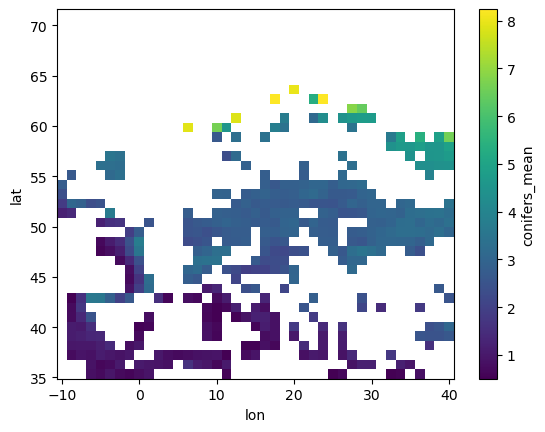

In [280]:
ssp_con.plot()

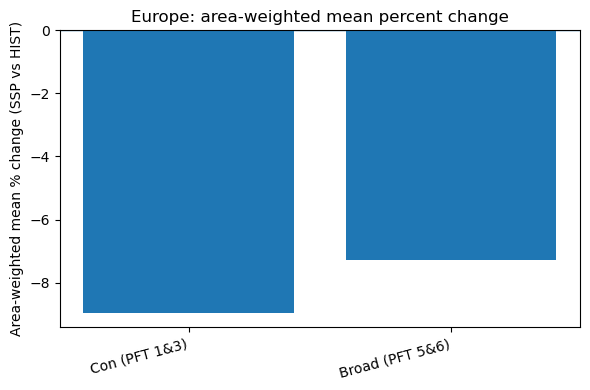

In [281]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Percent change maps (ssp vs hist) for each group ---
pchg_con   = (ssp_con   - hist_con)   / hist_con   * 100.0
pchg_broad = (ssp_broad - hist_broad) / hist_broad * 100.0

pchg_con = pchg_con.where(
    (pchg_con > -100) & (pchg_con < 100))
pchg_broad = pchg_broad.where(
    (pchg_broad > -100) & (pchg_broad < 100))

# --- 2) Area weights (cos(lat)) ---
# xarray will broadcast these across lon automatically
w = np.cos(np.deg2rad(pchg_con["lat"]))

# --- 3) Area-weighted mean percent change (ignore NaNs) ---
con_mean   = pchg_con.weighted(w).mean(("lat", "lon"), skipna=True).item()
broad_mean = pchg_broad.weighted(w).mean(("lat", "lon"), skipna=True).item()

# --- 4) Bar chart (two bars) ---
labels = ["Con (PFT 1&3)", "Broad (PFT 5&6)"]
vals   = [con_mean, broad_mean]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, vals)  # no explicit colors
ax.axhline(0, linewidth=1)
ax.set_ylabel("Area-weighted mean % change (SSP vs HIST)")
ax.set_title("Europe: area-weighted mean percent change")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [282]:
import os
import numpy as np
import xarray as xr

fd = '/glade/derecho/scratch/brendanc/VPD/growth_model/nonlin'

def load_da(filename):
    ds = xr.open_dataset(os.path.join(fd, filename))
    return ds['__xarray_dataarray_variable__']

# Load HIST 1978–2014

abies_hist        = load_da('abies_alba_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
fagus_hist        = load_da('fagus_sylvatica_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
fraxinus_hist     = load_da('fraxinus_excelsior_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
picea_hist        = load_da('picea_abies_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
quercus_pet_hist  = load_da('quercus_petraea_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
quercus_pub_hist  = load_da('quercus_pubescens_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
pinus_hist        = load_da('pinus_sylvestris_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')

years_hist = np.arange(1978, 2015)

def fix_hist(da):
    return da.assign_coords(time=("time", years_hist))

abies_hist        = fix_hist(abies_hist)
fagus_hist        = fix_hist(fagus_hist)
fraxinus_hist     = fix_hist(fraxinus_hist)
picea_hist        = fix_hist(picea_hist)
quercus_pet_hist  = fix_hist(quercus_pet_hist)
quercus_pub_hist  = fix_hist(quercus_pub_hist)
pinus_hist        = fix_hist(pinus_hist)

hist_all = xr.concat(
    [
        abies_hist.fillna(0),
        fagus_hist.fillna(0),
        fraxinus_hist.fillna(0),
        picea_hist.fillna(0),
        quercus_pet_hist.fillna(0),
        quercus_pub_hist.fillna(0),
        pinus_hist.fillna(0)
    ],
    dim="species"
)

In [283]:
hist_baseline = hist_all.sel(time=slice(1995, 2014)).mean("time")

In [284]:
import os
import numpy as np
import xarray as xr

fd = '/glade/derecho/scratch/brendanc/VPD/growth_model/nonlin'

def load_da(filename):
    ds = xr.open_dataset(os.path.join(fd, filename))
    return ds['__xarray_dataarray_variable__']

# Load HIST 1978–2014

abies_ssp        = load_da('abies_alba_SSP245_006_Europe_annual_radial_growth_2015-2069_nonlin.nc')
fagus_ssp         = load_da('fagus_sylvatica_SSP245_006_Europe_annual_radial_growth_2015-2069_nonlin.nc')
fraxinus_ssp      = load_da('fraxinus_excelsior_SSP245_006_Europe_annual_radial_growth_2015-2069_nonlin.nc')
picea_ssp         = load_da('picea_abies_SSP245_006_Europe_annual_radial_growth_2015-2069_nonlin.nc')
quercus_pet_ssp   = load_da('quercus_petraea_SSP245_006_Europe_annual_radial_growth_2015-2069_nonlin.nc')
quercus_pub_ssp   = load_da('quercus_pubescens_SSP245_006_Europe_annual_radial_growth_2015-2069_nonlin.nc')
pinus_ssp         = load_da('pinus_sylvestris_SSP245_006_Europe_annual_radial_growth_2015-2069_nonlin.nc')

years_ssp  = np.arange(2015, 2070)

def fix_ssp(da):
    return da.assign_coords(time=("time", years_ssp))

abies_ssp        = fix_ssp(abies_ssp)
fagus_ssp        = fix_ssp(fagus_ssp)
fraxinus_ssp     = fix_ssp(fraxinus_ssp)
picea_ssp        = fix_ssp(picea_ssp)
quercus_pet_ssp  = fix_ssp(quercus_pet_ssp)
quercus_pub_ssp  = fix_ssp(quercus_pub_ssp)
pinus_ssp        = fix_ssp(pinus_ssp)

species_names = [
    "Abies alba",
    "Fagus sylvatica",
    "Fraxinus excelsior",
    "Picea abies",
    "Quercus petraea",
    "Quercus pubescens",
    "Pinus sylvestris"
]

ssp_all = xr.concat(
    [
        abies_ssp.fillna(0),
        fagus_ssp.fillna(0),
        fraxinus_ssp.fillna(0),
        picea_ssp.fillna(0),
        quercus_pet_ssp.fillna(0),
        quercus_pub_ssp.fillna(0),
        pinus_ssp.fillna(0)
    ],
    dim="species"
).assign_coords(species=species_names)

In [285]:
ssp_all = ssp_all.sel(time=slice(2050, 2069)).mean("time")

In [286]:
def nanmean_over_dim(da, idx, dim):
    """NaN-aware mean that keeps single values unchanged (sum / count of non-NaN)."""
    sub = da.isel({dim: idx})
    n   = sub.notnull().sum(dim=dim)
    s   = sub.sum(dim=dim, skipna=True)
    return s / n

# groups (0-based species indexing)
con_idx   = [0, 3, 6]
broad_idx = [1, 2, 4, 5]

# ---- HIST baseline (species, lat, lon) -> (group, lat, lon)
hist_con_obs  = nanmean_over_dim(hist_baseline, con_idx,   dim="species").rename("con")
hist_broad_obs = nanmean_over_dim(hist_baseline, broad_idx, dim="species").rename("broad")

# ---- SSP all (species, time, lat, lon) -> (group, time, lat, lon)
ssp_con_obs   = nanmean_over_dim(ssp_all, con_idx,   dim="species").rename("con")
ssp_broad_obs = nanmean_over_dim(ssp_all, broad_idx, dim="species").rename("broad")

In [287]:
ssp_broad_obs

<xarray.DataArray 'broad' (lat: 39, lon: 41)> Size: 13kB
array([[0.        , 0.        , 0.        , ..., 0.07674697, 0.1155163 ,
        0.07562285],
       [0.        , 0.        , 0.        , ..., 0.07578258, 0.06601535,
        0.06108106],
       [0.        , 0.11321741, 0.10136724, ..., 0.09456439, 0.07351151,
        0.06619154],
       ...,
       [0.        , 0.        , 0.        , ..., 1.96173324, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])
Coordinates:
  * lat      (lat) float64 312B 35.34 36.28 37.23 38.17 ... 69.27 70.21 71.15
  * lon      (lon) float64 328B -10.0 -8.75 -7.5 -6.25 ... 36.25 37.5 38.75 40.0

In [288]:
import xarray as xr
import numpy as np

# choose an "authoritative" grid (obs grid)
lat_t = ssp_broad_obs["lat"]
lon_t = ssp_broad_obs["lon"]

def on_template_grid(da):
    # overwrite coords to be exactly the template values (assumes same shape/order)
    return da.assign_coords(lat=lat_t, lon=lon_t)

# put all fields on exactly the same lat/lon coords
hist_con_obs    = on_template_grid(hist_con_obs)
ssp_con_obs     = on_template_grid(ssp_con_obs)
hist_broad_obs  = on_template_grid(hist_broad_obs)
ssp_broad_obs   = on_template_grid(ssp_broad_obs)

In [289]:
mask_con   = ssp_con.notnull()          # True where conifers exist in SSP
mask_broad = ssp_broad.notnull()        # True where broadleaf exist in SSP (if SSP uses NaN)

In [290]:
mask_con_fix = mask_con.assign_coords(lat=hist_con_obs.lat)
mask_broad_fix = mask_broad.assign_coords(lat=hist_broad_obs.lat)

hist_con_obs_mask   = hist_con_obs.where(mask_con_fix)
ssp_con_obs_mask    = ssp_con_obs.where(mask_con_fix)

hist_broad_obs_mask = hist_broad_obs.where(mask_broad_fix)
ssp_broad_obs_mask  = ssp_broad_obs.where(mask_broad_fix)

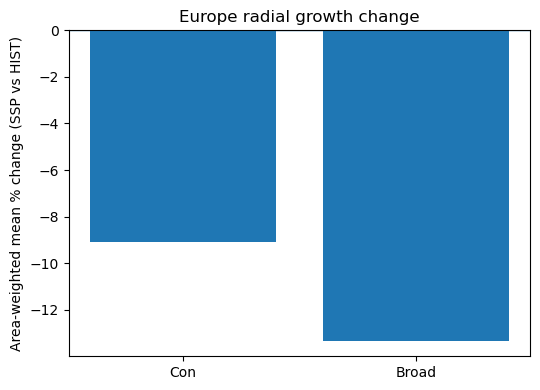

In [291]:
# --- percent change ---
pchg_con   = (ssp_con_obs   - hist_con_obs)   / hist_con_obs   * 100
pchg_broad = (ssp_broad_obs - hist_broad_obs) / hist_broad_obs * 100

# avoid divide-by-zero or meaningless percent change
pchg_con   = pchg_con.where(hist_con_obs != 0)
pchg_broad = pchg_broad.where(hist_broad_obs != 0)

# --- area weights ---
weights = np.cos(np.deg2rad(pchg_con["lat"]))

# --- area-weighted means ---
con_mean_obs   = pchg_con.weighted(weights).mean(("lat", "lon"), skipna=True).item()
broad_mean_obs = pchg_broad.weighted(weights).mean(("lat", "lon"), skipna=True).item()

# --- bar plot ---
labels = ["Con", "Broad"]
vals   = [con_mean_obs, broad_mean_obs]

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(labels, vals)   # no explicit colors
ax.axhline(0, linewidth=1)
ax.set_ylabel("Area-weighted mean % change (SSP vs HIST)")
ax.set_title("Europe radial growth change")
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/glade/derecho/scratch/brendanc/fates_output/constco2/GRL_Figures/GRL_Fig4.png'

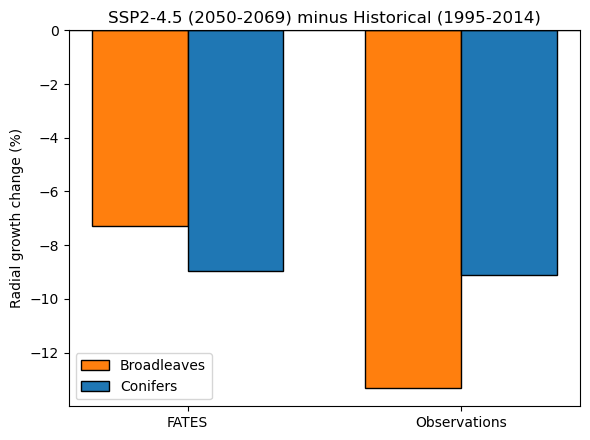

In [294]:
# use the already-computed means from your two separate scripts
fates_con  = con_mean          # from your FATES plot script
fates_brd  = broad_mean        # from your FATES plot script

obs_con    = con_mean_obs      # <-- set these to the con_mean/broad_mean from your OBS script
obs_brd    = broad_mean_obs    # <-- set these to the con_mean/broad_mean from your OBS script

# If you *didn't* rename them, and you ran the OBS script after FATES,
# then con_mean/broad_mean now refer to OBS. In that case, do this instead:
# fates_con, fates_brd = fates_con_mean, fates_broad_mean
# obs_con, obs_brd     = con_mean, broad_mean

groups = ["FATES", "Observations"]
x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4.5))

# Broadleaves on the LEFT of each group
ax.bar(
    x - width/2,
    [fates_brd, obs_brd],
    width,
    label="Broadleaves",
    color="tab:orange",
    edgecolor="black",
)

# Conifers on the RIGHT of each group
ax.bar(
    x + width/2,
    [fates_con, obs_con],
    width,
    label="Conifers",
    color="tab:blue",
    edgecolor="black",
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel("Radial growth change (%)")
ax.set_title("SSP2-4.5 (2050-2069) minus Historical (1995-2014)")

# legend order: Broadleaves first, then Conifers
handles, labels = ax.get_legend_handles_labels()
order = [0, 1]
ax.legend([handles[i] for i in order], [labels[i] for i in order])

plt.tight_layout()
savedir = "/glade/derecho/scratch/brendanc/fates_output/constco2/GRL_Figures"
plt.savefig(f"{savedir}/GRL_Fig4.png", dpi=300, bbox_inches="tight")
#plt.show()